

---



---


**Task 2 — Analyze Dataset Visually & Statistically**

---



---



**MOUNT GOOGLE DRIVE**

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**DEFINE DATASET PATH**

In [2]:
from pathlib import Path

DATASET_PATH = Path(
    "/content/drive/My Drive/chest-xray-pneumonia-detection/Dataset/chest_xray/chest_xray"
)

print("Dataset Path Loaded Successfully")

Dataset Path Loaded Successfully


In [3]:
import os
print(os.listdir(DATASET_PATH))

['.DS_Store', 'test', 'train', 'val']


**IMPORT REQUIRED LIBRARIES**

In [4]:
# File System Handling
import os
from pathlib import Path
from glob import glob

# Image Processing
import cv2
from PIL import Image

# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Random Sampling
import random

import numpy as np
import seaborn as sns

**VERIFY DATASET STRUCTURE**

In [5]:
splits = ['train', 'test', 'val']
classes = ['NORMAL', 'PNEUMONIA']

print("="*50)
print("DATASET STRUCTURE VERIFICATION")
print("="*50)
for split in splits:
    split_path = DATASET_PATH / split
    if split_path.exists():
        print(f"\n {split.upper()} folder found")
        for cls in classes:
            class_path = split_path / cls
            if class_path.exists():
                total_images = len(glob(str(class_path / "*")))
                print(f"   |-- {cls:<12}: {total_images} images")
            else:
                print(f"   |-- Missing class folder: {cls}")
    else:
        print(f"\nMissing split folder: {split}")

DATASET STRUCTURE VERIFICATION

 TRAIN folder found
   |-- NORMAL      : 1341 images
   |-- PNEUMONIA   : 3875 images

 TEST folder found
   |-- NORMAL      : 234 images
   |-- PNEUMONIA   : 390 images

 VAL folder found
   |-- NORMAL      : 8 images
   |-- PNEUMONIA   : 8 images


**DYNAMIC GRID VISUALIZATION**

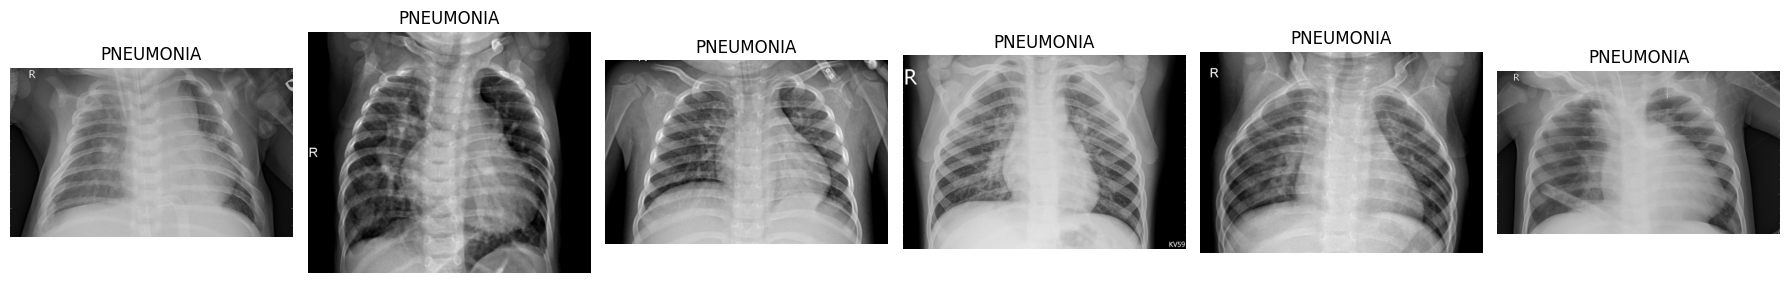

In [6]:
# Number of samples per class
samples_per_class = 6

normal_images = random.sample(
    glob(str(DATASET_PATH / "train" / "NORMAL" / "*")),
    samples_per_class
)

pneumonia_images = random.sample(
    glob(str(DATASET_PATH / "train" / "PNEUMONIA" / "*")),
    samples_per_class
)

plt.figure(figsize=(18,10))
# Display NORMAL images
for i, image_path in enumerate(normal_images):
    img = Image.open(image_path)
    plt.subplot(2, samples_per_class,samples_per_class+ i + 1)
    plt.imshow(img, cmap='gray')
    plt.title("NORMAL")
    plt.axis("off")
# Display PNEUMONIA images
for i, image_path in enumerate(pneumonia_images):
    img = Image.open(image_path)
    plt.subplot(2, samples_per_class, samples_per_class + i + 1)
    plt.imshow(img, cmap='gray')
    plt.title("PNEUMONIA")
    plt.axis("off")
plt.tight_layout()
plt.show()

**CLASS DISPARITY PROPORTIONS**

In [9]:
import os

os.makedirs("react_outputs", exist_ok=True)

print("Folder created successfully")

Folder created successfully


,Class,Count
0,NORMAL,1341
1,PNEUMONIA,3875


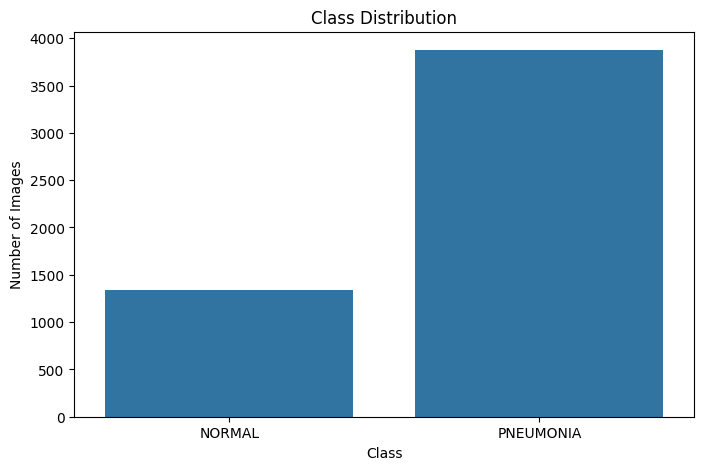

Imbalance Coefficient: 2.89


In [10]:
class_counts={
    "NORMAL":len(glob(str(DATASET_PATH/"train"/"NORMAL"/"*"))),
    "PNEUMONIA":len(glob(str(DATASET_PATH/"train"/"PNEUMONIA"/"*")))
}

class_df=pd.DataFrame({
    "Class":list(class_counts.keys()),
    "Count":list(class_counts.values())
})

display(class_df)

plt.figure(figsize=(8,5))
sns.barplot(data=class_df,x="Class",y="Count")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.savefig("react_outputs/class_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

imbalance_ratio=class_counts["PNEUMONIA"]/class_counts["NORMAL"]
print(f"Imbalance Coefficient: {imbalance_ratio:.2f}")

class_df.to_json(
    "react_outputs/class_distribution.json",
    orient="records"
)

**RESOLUTION TRAJECTORY ANALYSIS**

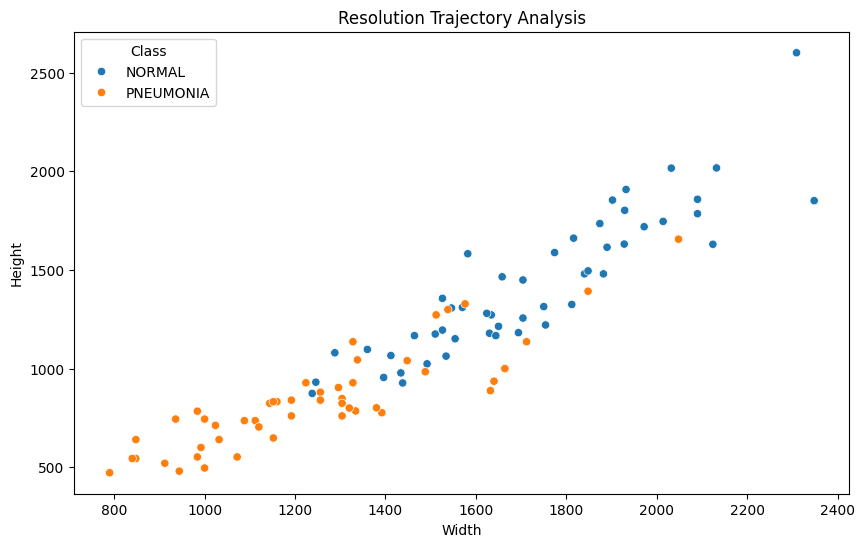

In [11]:
image_widths=[]
image_heights=[]
image_labels=[]

sample_size=50

for cls in classes:
    image_files=glob(str(DATASET_PATH/"train"/cls/"*"))
    sampled_files=random.sample(image_files,min(sample_size,len(image_files)))

    for image_path in sampled_files:
        try:
            img=Image.open(image_path)
            width,height=img.size

            image_widths.append(width)
            image_heights.append(height)
            image_labels.append(cls)

        except:
            pass

resolution_df=pd.DataFrame({
    "Width":image_widths,
    "Height":image_heights,
    "Class":image_labels
})

plt.figure(figsize=(10,6))
sns.scatterplot(data=resolution_df,x="Width",y="Height",hue="Class")
plt.title("Resolution Trajectory Analysis")
plt.xlabel("Width")
plt.ylabel("Height")
plt.savefig("react_outputs/resolution_analysis.png",dpi=300,bbox_inches="tight")
plt.show()

**PIXEL INTENSITY DISTRIBUTION**

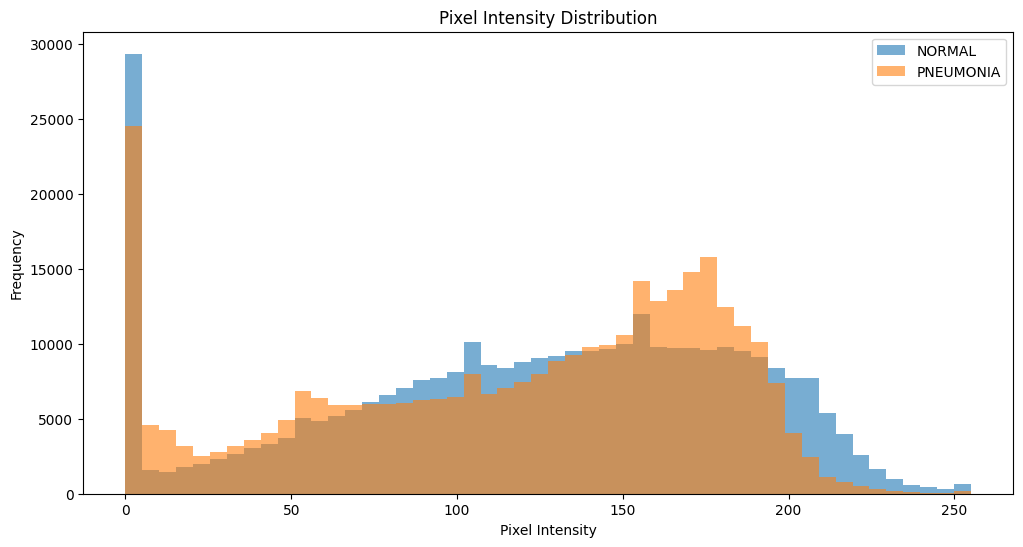

In [12]:
normal_pixels=[]
pneumonia_pixels=[]

hist_sample_size=20

normal_files=random.sample(
    glob(str(DATASET_PATH/"train"/"NORMAL"/"*")),
    hist_sample_size
)

for image_path in normal_files:
    img=cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
    img=cv2.resize(img,(128,128))
    normal_pixels.extend(img.flatten())

pneumonia_files=random.sample(
    glob(str(DATASET_PATH/"train"/"PNEUMONIA"/"*")),
    hist_sample_size
)

for image_path in pneumonia_files:
    img=cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
    img=cv2.resize(img,(128,128))
    pneumonia_pixels.extend(img.flatten())

plt.figure(figsize=(12,6))
plt.hist(normal_pixels,bins=50,alpha=0.6,label="NORMAL")
plt.hist(pneumonia_pixels,bins=50,alpha=0.6,label="PNEUMONIA")
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("react_outputs/pixel_intensity_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

**STRUCTURAL ARTIFACT AUDIT**

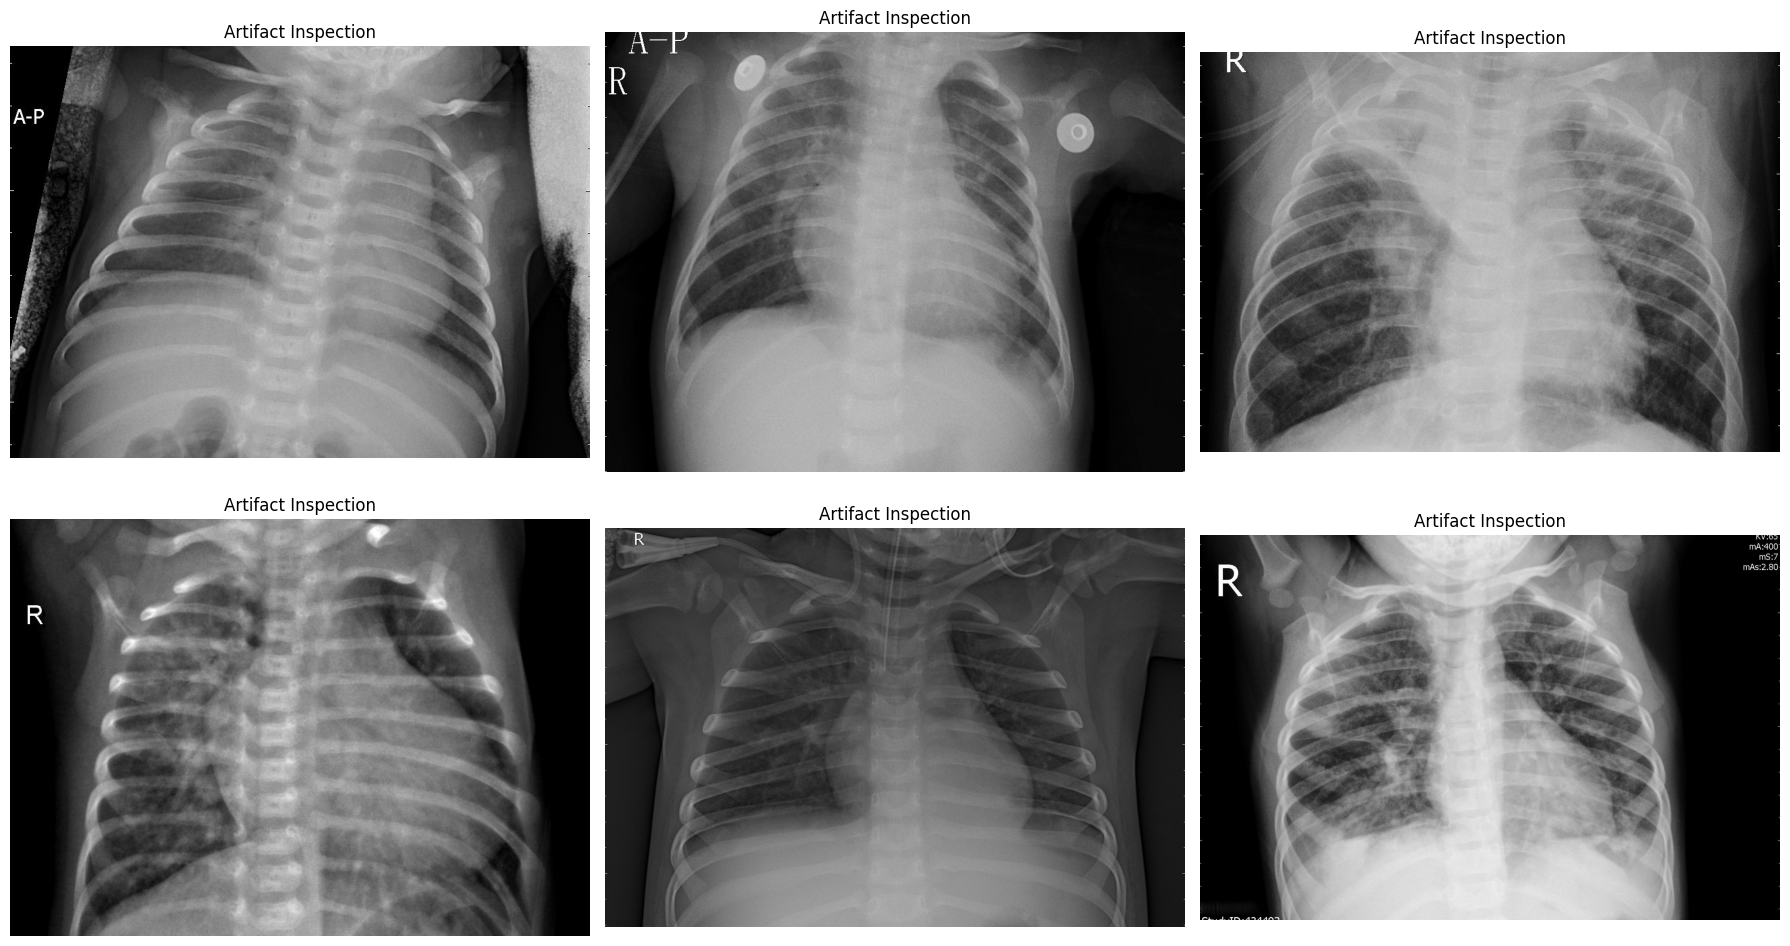

In [13]:
artifact_images = random.sample(
    glob(str(DATASET_PATH / "train" / "PNEUMONIA" / "*")),6
)
plt.figure(figsize=(18,10))

for i, image_path in enumerate(artifact_images):
    img = Image.open(image_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title("Artifact Inspection")
    plt.axis("off")
plt.tight_layout()
plt.show()

**SAVE EDA REPORTS**

In [14]:
os.makedirs("eda_reports", exist_ok=True)

# Save class distribution
class_df.to_csv(
    "eda_reports/class_distribution.csv",
    index=False
)
# Save resolution analysis
resolution_df.to_csv(
    "eda_reports/resolution_analysis.csv",
    index=False
)
print("EDA reports saved successfully.")

EDA reports saved successfully.
